In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')

output_dir = '../../../public/graphs/social_media_usage'
os.makedirs(output_dir, exist_ok=True)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("\nII. DATA LOADING AND INITIAL ASSESSMENT")

df = pd.read_csv('../../data/social_media_usage.csv')
df


II. DATA LOADING AND INITIAL ASSESSMENT


,User_ID,App,Daily_Minutes_Spent,Posts_Per_Day,Likes_Per_Day,Follows_Per_Day
0,U_1,Pinterest,288,16,94,0
1,U_2,Facebook,192,14,117,15
2,U_3,Instagram,351,13,120,48
3,U_4,TikTok,21,20,117,8
4,U_5,LinkedIn,241,16,9,21
...,...,...,...,...,...,...
995,U_996,LinkedIn,479,4,72,15
996,U_997,Instagram,499,14,110,49
997,U_998,Facebook,318,6,105,9
998,U_999,TikTok,305,15,151,6


In [3]:
# // installing pandas locally
# import sys
# print(sys.executable) //shows your python.exe path
# [path] -m pip install [libraries]

In [4]:
# Information on the dimensions, column titles, and data types (of the columns)
print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Data Types:\n{df.dtypes}")

# example of the first couple rows
print(df.head())

Dataset Shape: (1000, 6)
Columns: ['User_ID', 'App', 'Daily_Minutes_Spent', 'Posts_Per_Day', 'Likes_Per_Day', 'Follows_Per_Day']
Data Types:
User_ID                object
App                    object
Daily_Minutes_Spent     int64
Posts_Per_Day           int64
Likes_Per_Day           int64
Follows_Per_Day         int64
dtype: object
  User_ID        App  Daily_Minutes_Spent  Posts_Per_Day  Likes_Per_Day  \
0     U_1  Pinterest                  288             16             94   
1     U_2   Facebook                  192             14            117   
2     U_3  Instagram                  351             13            120   
3     U_4     TikTok                   21             20            117   
4     U_5   LinkedIn                  241             16              9   

   Follows_Per_Day  
0                0  
1               15  
2               48  
3                8  
4               21  


# III. Data Cleaning and Preparation

In [5]:
print("\nIII. DATA CLEANING AND PREPARATION")
# 1. Missing Value Analysis
print("\n1. Missing Value Analysis:")
missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df)) * 100
missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_percentage
})
print(missing_summary[missing_summary['Missing_Count'] > 0]) # print the rows that have a missing count > 0

# 2. Data Type Validation and Conversion
print("\n2. Data Type Validation:")
print(df.dtypes)

    ## Convert categorical variables
categorical_cols = ['App']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

print("\nUpdated data type(s):")
print(df.dtypes)

# 3. Outlier Detection
print("\n3. Outlier Detection:")

def detect_outliers(df, column):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = (Q3-Q1)*1.5
    lower_bound = Q1-IQR
    upper_bound = Q3+IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column]  > upper_bound)] # returns rows that are an outlier of the column
    return outliers, upper_bound, lower_bound # want to display the upper and lower bound for the post

numeric_columns = ['Daily_Minutes_Spent', 'Posts_Per_Day', 'Likes_Per_Day', 'Follows_Per_Day']

outlier_summary = {}
for col in numeric_columns:
    outliers, upper, lower = detect_outliers(df, col)
    outlier_summary[col] = {
        'outlier_count': len(outliers),
        'outlier_percentage': (len(outliers) / len(df)) * 100,
        'lower_bound': lower,
        'upper_bound': upper
    }
print("Outlier Summary:")
for col, info in outlier_summary.items():
    print(f"  {col}: {info['outlier_count']} outliers ({info['outlier_percentage']:.1f}%)")

# for col in outlier_summary:
#     print(outlier_summary[col])


III. DATA CLEANING AND PREPARATION

1. Missing Value Analysis:
Empty DataFrame
Columns: [Missing_Count, Missing_Percentage]
Index: []

2. Data Type Validation:
User_ID                object
App                    object
Daily_Minutes_Spent     int64
Posts_Per_Day           int64
Likes_Per_Day           int64
Follows_Per_Day         int64
dtype: object

Updated data type(s):
User_ID                  object
App                    category
Daily_Minutes_Spent       int64
Posts_Per_Day             int64
Likes_Per_Day             int64
Follows_Per_Day           int64
dtype: object

3. Outlier Detection:
Outlier Summary:
  Daily_Minutes_Spent: 0 outliers (0.0%)
  Posts_Per_Day: 0 outliers (0.0%)
  Likes_Per_Day: 0 outliers (0.0%)
  Follows_Per_Day: 0 outliers (0.0%)


In [6]:
# 4. Data Consistency Checks
print("\n4. Data Consistency Checks:")

# Check for logical inconsistencies
print(f"Daily_Minutes_Spent range: {df['Daily_Minutes_Spent'].min()} - {df['Daily_Minutes_Spent'].max()}")
print(f"Posts_Per_Day range: {df['Posts_Per_Day'].min():.1f} - {df['Posts_Per_Day'].max():.1f} posts")
print(f"Likes_Per_Day range: {df['Likes_Per_Day'].min()} - {df['Likes_Per_Day'].max()}")
print(f"Follows_Per_Day range: {df['Follows_Per_Day'].min()} - {df['Follows_Per_Day'].max()} followers")

# Create cleaned dataset (remove outliers for analysis)
df_clean = df.copy()
for col in numeric_columns:
    if col in df.columns and outlier_summary[col]['outlier_percentage'] > 5:
        outliers, lower, upper = detect_outliers(df, col)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f"\nRecords after outlier removal: {len(df_clean)} (from {len(df)})")


4. Data Consistency Checks:
Daily_Minutes_Spent range: 5 - 500
Posts_Per_Day range: 0.0 - 20.0 posts
Likes_Per_Day range: 0 - 200
Follows_Per_Day range: 0 - 50 followers

Records after outlier removal: 1000 (from 1000)


# IV. EXPLORATORY DATA ANALYSIS (EDA)


IV. EXPLORATORY DATA ANALYSIS (EDA)
--------------------------------------------------

1. Descriptive Statistics:
       Daily_Minutes_Spent  Posts_Per_Day  Likes_Per_Day  Follows_Per_Day
count          1000.000000    1000.000000    1000.000000      1000.000000
mean            247.368000      10.269000      94.682000        24.698000
std             146.371921       6.121774      57.560943        14.842948
min               5.000000       0.000000       0.000000         0.000000
25%             112.750000       5.000000      44.750000        12.000000
50%             246.000000      10.000000      94.000000        24.000000
75%             380.500000      16.000000     142.000000        38.000000
max             500.000000      20.000000     200.000000        50.000000

2. Distribution Analysis:


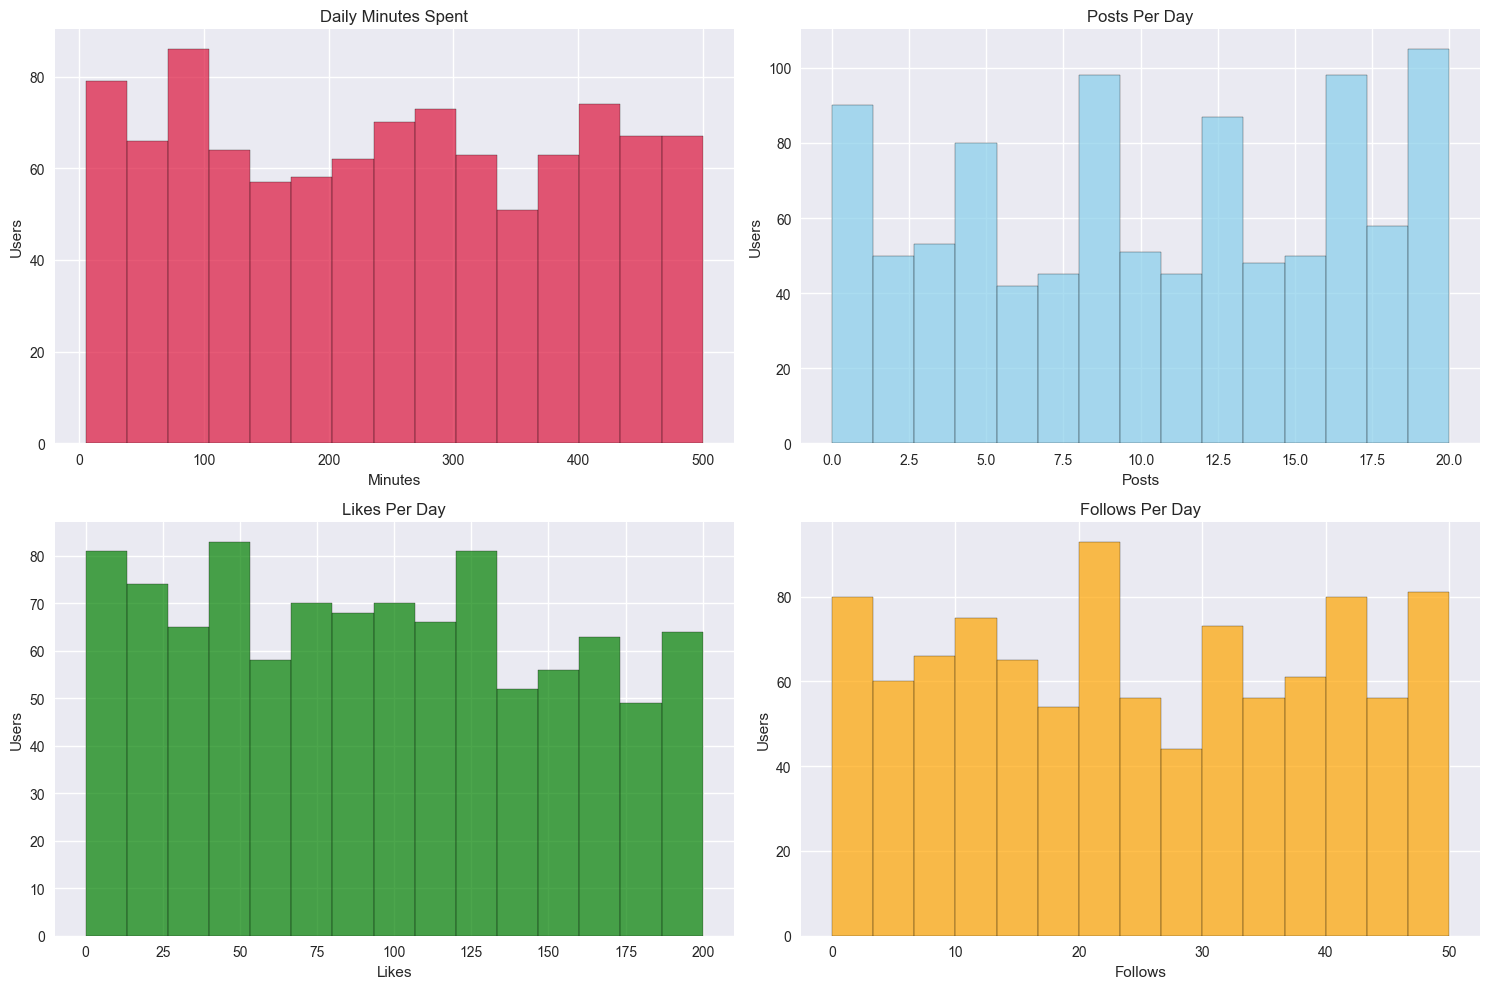

In [7]:
print("\nIV. EXPLORATORY DATA ANALYSIS (EDA)")
print("-" * 50)

# 1. Descriptive Statistics
print("\n1. Descriptive Statistics:")
summary_stats = df_clean[numeric_columns].describe()
print(summary_stats)

# 2. Distribution Analysis
print("\n2. Distribution Analysis:")

# Figure Default Scale
plt.figure(figsize=(15, 10))

# Daily Minutes Spent (All Apps)
plt.subplot(2,2,1)
plt.hist(df_clean['Daily_Minutes_Spent'], bins = 15, alpha =.7, color = 'crimson', edgecolor= 'black')
plt.title("Daily Minutes Spent")
plt.xlabel("Minutes")
plt.ylabel("Users")

# Posts Per Day (All Apps)
plt.subplot(2,2,2)
plt.hist(df_clean['Posts_Per_Day'], bins = 15, alpha =.7, color = 'skyblue', edgecolor= 'black')
plt.title("Posts Per Day")
plt.xlabel("Posts")
plt.ylabel("Users")

# Likes Per Day (All Apps)
plt.subplot(2,2,3)
plt.hist(df_clean['Likes_Per_Day'], bins = 15, alpha =.7, color = 'green', edgecolor= 'black')
plt.title("Likes Per Day")
plt.xlabel("Likes")
plt.ylabel("Users")

# Follows Per Day (All Apps)
plt.subplot(2,2,4)
plt.hist(df_clean['Follows_Per_Day'], bins = 15, alpha =.7, color = 'orange', edgecolor= 'black')
plt.title("Follows Per Day")
plt.xlabel("Follows")
plt.ylabel("Users")

# Finalize graphs and save and clear
plt.tight_layout()
# plt.savefig(f'{output_dir}/social_media_usage.png', dpi=300, bbox_inches='tight')
# plt.close()



3. Distribution Analysis (By App):


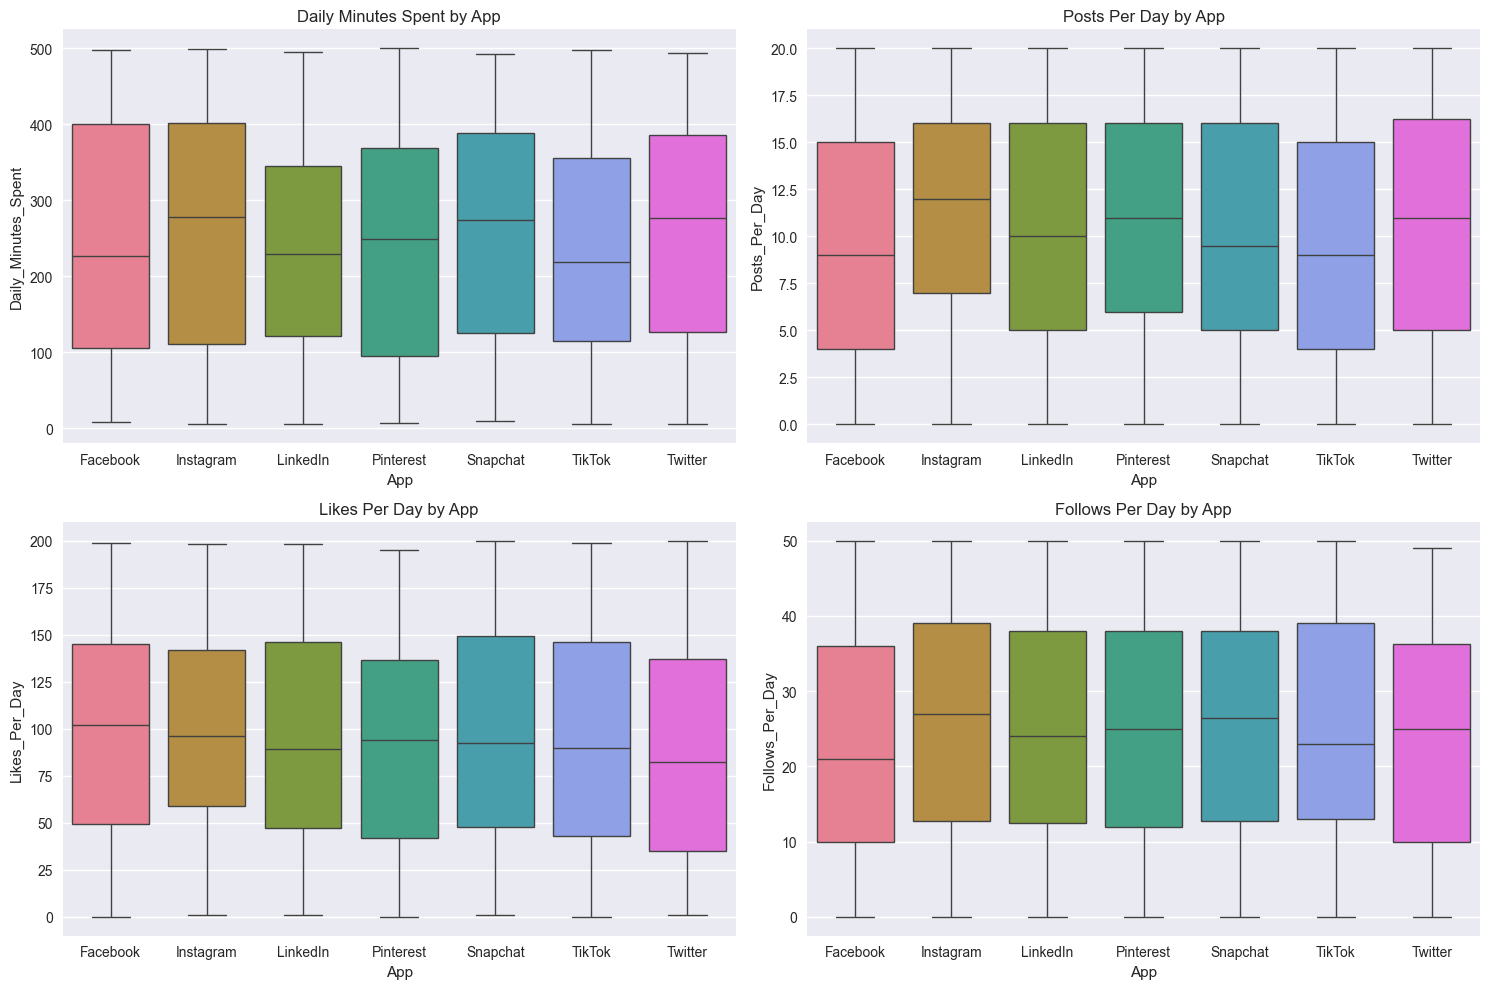

In [8]:
# Boxplots grouped by App
print("\n3. Distribution Analysis (By App):")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x='App', y='Daily_Minutes_Spent', data=df_clean, ax=axes[0,0], palette="husl")
axes[0,0].set_title("Daily Minutes Spent by App")

sns.boxplot(x='App', y='Posts_Per_Day', data=df_clean, ax=axes[0,1], palette="husl")
axes[0,1].set_title("Posts Per Day by App")

sns.boxplot(x='App', y='Likes_Per_Day', data=df_clean, ax=axes[1,0], palette="husl")
axes[1,0].set_title("Likes Per Day by App")

sns.boxplot(x='App', y='Follows_Per_Day', data=df_clean, ax=axes[1,1], palette="husl")
axes[1,1].set_title("Follows Per Day by App")

plt.tight_layout()
# plt.savefig(f'{output_dir}/social_media_usage_boxplots.png', dpi=300, bbox_inches='tight')
# plt.close()

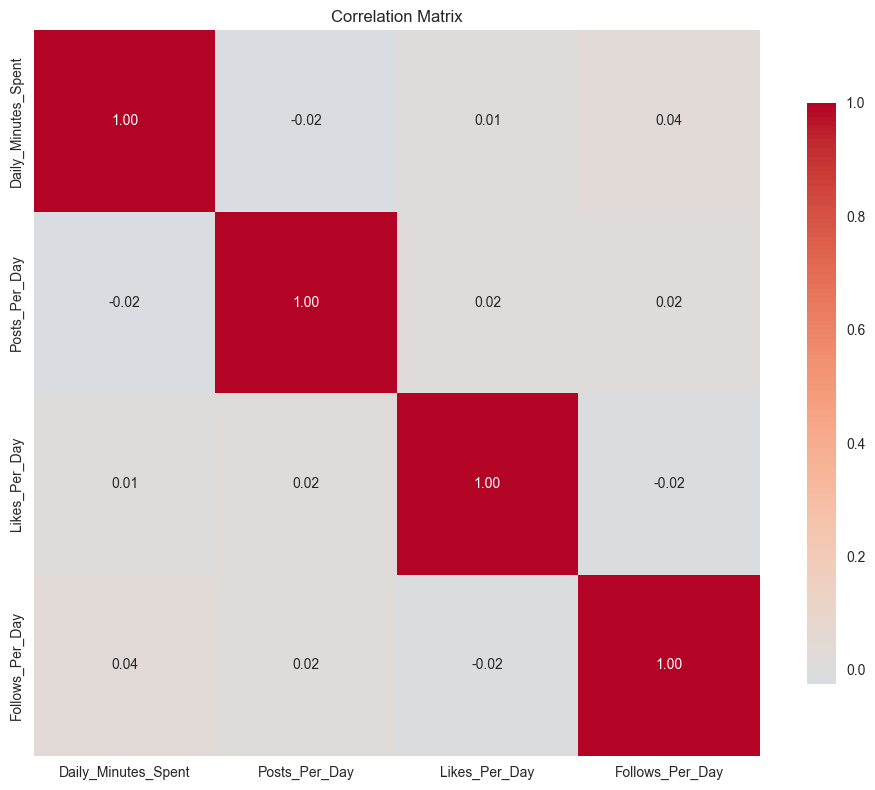

In [ ]:
print("\n3. Correlation Analysis:")

correl_matrix = df_clean[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correl_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f', cbar_kws={'shrink': 0.8})

plt.title('Social Media Usage Correlation Matrix')
plt.tight_layout()
# plt.savefig(f'{output_dir}/social_media_corr_heatmap.png', dpi=300, bbox_inches='tight')
# plt.close()

# The heatmap suggests no correlation between the independent variables

# V. STATISTICAL ANALYSIS AND MODELING

In [22]:
print("\nV. STATISTICAL ANALYSIS AND MODELING")

# 1. Statistical Tests
print("\n1. Statistical Tests:")

independent_vars = [
    'Daily_Minutes_Spent',
    'Likes_Per_Day',
    'Posts_Per_Day',
    'Follows_Per_Day'
]

# Normality Tests for each Independent Variable (Numeric) 
for var in independent_vars:
    shapiro_test = stats.shapiro(df_clean[var])
    print(f"Shapiro-Wilk Test for {var}:")
    print(f"  Statistic: {shapiro_test.statistic:.4f}")
    print(f"  P-value: {shapiro_test.pvalue:.4f}")
    print(f"  Normal distribution: {'No' if shapiro_test.pvalue < 0.05 else 'Yes'}\n")
print(f"All Distributions Violate Normality\n")


V. STATISTICAL ANALYSIS AND MODELING

1. Statistical Tests:
Shapiro-Wilk Test for Daily_Minutes_Spent:
  Statistic: 0.9489
  P-value: 0.0000
  Normal distribution: No

Shapiro-Wilk Test for Likes_Per_Day:
  Statistic: 0.9556
  P-value: 0.0000
  Normal distribution: No

Shapiro-Wilk Test for Posts_Per_Day:
  Statistic: 0.9457
  P-value: 0.0000
  Normal distribution: No

Shapiro-Wilk Test for Follows_Per_Day:
  Statistic: 0.9501
  P-value: 0.0000
  Normal distribution: No

All Distributions Violate Normality



In [ ]:
print(f"\nRECOMMENDATION: Use non-parametric results since data is not normally distributed.")

# Non-parametric: Spearman Correlation (more appropriate for non-normal data)
spearman_corr, spearman_p = stats.spearmanr(df_clean['Sleep Duration'], df_clean['Quality of Sleep'])
print(f"  Spearman Correlation (non-parametric):")
print(f"    Correlation: {spearman_corr:.4f}")
print(f"    P-value: {spearman_p:.4f}")
print(f"    Significant: {'Yes' if spearman_p < 0.05 else 'No'}")

# Non-parametric: Mann-Whitney U test
u_stat, u_p_value = stats.mannwhitneyu(,alternative='two-sided')
print(f"  Mann-Whitney U test (non-parametric):")
print(f"    U-statistic: {u_stat:.4f}")
print(f"    P-value: {u_p_value:.4f}")
print(f"    Significant difference: {'Yes' if u_p_value < 0.05 else 'No'}")


print(f"  - Spearman correlation: {spearman_corr:.4f} (p = {spearman_p:.4f})")
print(f"  - Mann-Whitney U test: U = {u_stat:.4f} (p = {u_p_value:.4f})")


RECOMMENDATION: Use non-parametric results since data is not normally distributed.


KeyError: 'Sleep Duration'

# VI. ANALYSIS AND INTERPRETATION

In [ ]:
print("\nVI. ANALYSIS AND INTERPRETATION")

# 1. Key Findings Summary
print("\n1. Key Findings Summary:")